# Proof of concept: Matrix Wavelet Transforms in 2D with CVXPY
February 16, 2024

We've shown that it is possible to perform the wavelet deconstruction and reconstruction using matrix transformations in 1D.

Now, it is a bit more complicated to perform this in 2D, but we may be able to leverage the fact that the operations for 2D wavelet transforms are essential still in the 1D at a time—across the rows or columns.

We can start by determing if we can do this in numpy with the LL filter only. That is low-horizontal pass along the rows, followed by a low-vertical pass along the columns.

Then, reversed to perform the reconstruction.


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
import numpy as np
import pywt

In [3]:
# let's start with a 16x16 of a chromatin image

from cc_src.chromatin_model import ChromatinModel
from src.config import load_yl_replicate1_rg1_alpha_vst_config

config = load_yl_replicate1_rg1_alpha_vst_config()
chromatin_model = ChromatinModel(config)
chromatin_model.load_mnase_gene('CLN1', replicate=1)

Loading MNase reads for CLN1...Done.


In [4]:
chromatin_model.create_deconvolution_bins(smoothing=False)

Unflattened the input data is of shape: (16, 16, 50)
The size of our input data, G is: (16, 800)


In [5]:
from src.wavelets_2d_linalg import pad_image

In [6]:
chromatin_model.deconv_hist_unflattened[0].shape
image = chromatin_model.deconv_hist_unflattened[0]
padded_image = pad_image(image, 8, 8)
padded_image.shape


(32, 66)

In [7]:
import pywt

wavelet = pywt.Wavelet('bior4.4')

dec_lo, dec_hi = wavelet.dec_lo, wavelet.dec_hi
rec_lo, rec_hi = wavelet.rec_lo, wavelet.rec_hi

In [182]:
from src.linalg_wavelets import create_downsample_convolution_matrix, \
    create_upsample_convolution_matrix
from src.wavelets_2d_linalg import create_wavelet2d_convolution_matrices

# Assume a square image for now
n, m = padded_image.shape[0], padded_image.shape[1]

(decomp_mats, recon_mats) = create_wavelet2d_convolution_matrices(wavelet, (n, m))


In [183]:
from src.wavelets_2d_linalg import wave2d_decomposition
from src.wavelets_2d_linalg import wave2d_reconstruction

coeffs = wave2d_decomposition(padded_image, decomp_mats)
reconstructed = wave2d_reconstruction(coeffs, recon_mats)


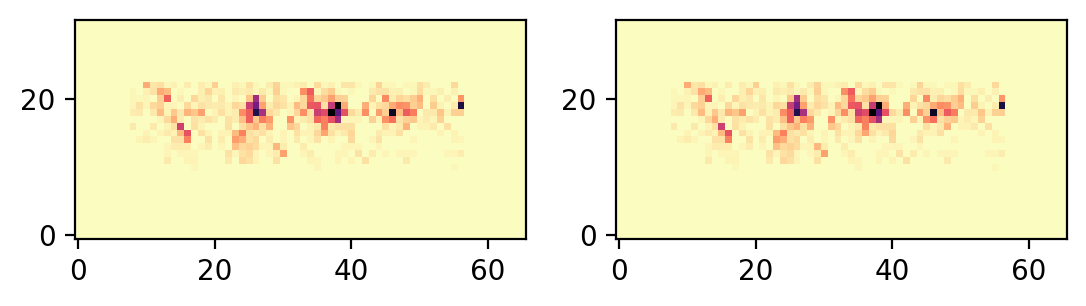

In [184]:
plt.subplot(1, 2, 1)
plt.imshow(padded_image, cmap='magma_r', origin='lower')

plt.subplot(1, 2, 2)
reconstructed[reconstructed < 0] = 0
plt.imshow(reconstructed, cmap='magma_r', origin='lower')


Next, are we able to perform a cvxpy decomposition and reconstruction in an optimization problem

Let's start with a the reconstruction of a single image.


In [185]:
import cvxpy

image = padded_image
img_shape = image.shape
image_flattened = image.flatten()

decomp_mats, recon_mats = create_wavelet2d_convolution_matrices(wavelet, img_shape)

(up_lo_horizontal_mat, up_lo_vertical_mat, 
 up_hi_horizontal_mat, up_hi_vertical_mat) = recon_mats

# Decomposition
LL_shape = LL.shape
LL_flattened = cvxpy.Variable((LL.shape[0]*LL.shape[1]))
LL = LL_flattened.reshape(LL_shape)

# Reconstruction
reconstruction = up_lo_vertical_mat.T@LL@up_lo_horizontal_mat
reconstruction_flattened = reconstruction.reshape(-1, order='C')

objective = cvxpy.Minimize(
    cvxpy.sum_squares(image_flattened - reconstruction_flattened) +
    0.01*cvxpy.sum(-reconstruction_flattened)
)

constraints = []

# Perform the convex optimization
prob = cvxpy.Problem(objective, constraints)

# The epsilon value affects the precision of the solver
result = prob.solve(solver=cvxpy.MOSEK, verbose=True)


                                     CVXPY                                     
                                     v1.4.1                                    
(CVXPY) Feb 16 03:27:43 PM: Your problem has 528 variables, 0 constraints, and 0 parameters.
(CVXPY) Feb 16 03:27:43 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Feb 16 03:27:43 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Feb 16 03:27:43 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Feb 16 03:27:43 PM: Your problem is compiled with the CPP canonicalization backend.
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
(CVXPY) Feb 16 03:27:43 PM: Compiling problem (target solver=MOSEK).
(C

0

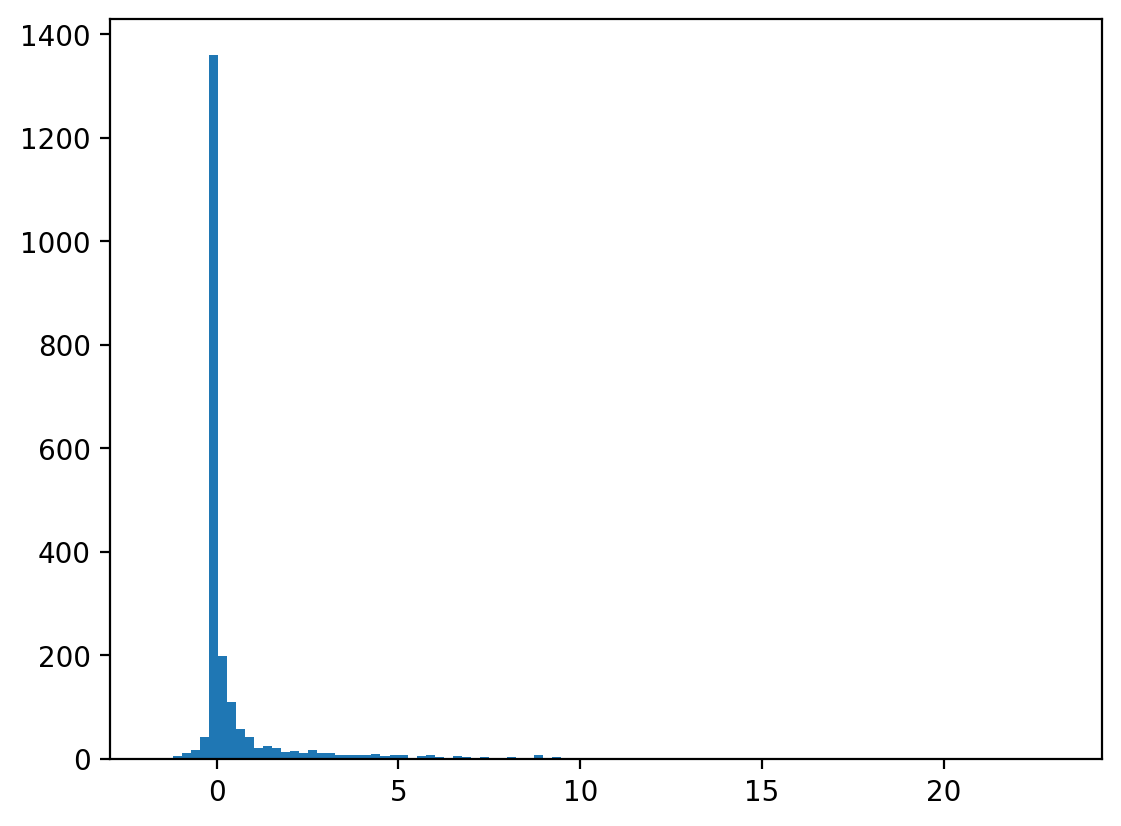

In [186]:
plt.hist(reconstruction.value.flatten(), bins=100)
0

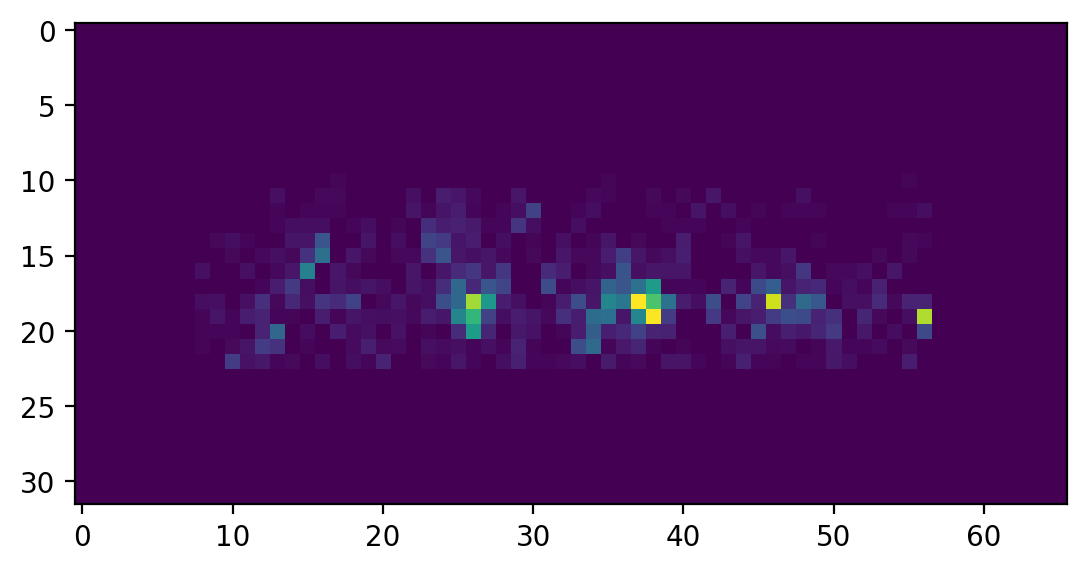

In [187]:
plt.imshow(image)

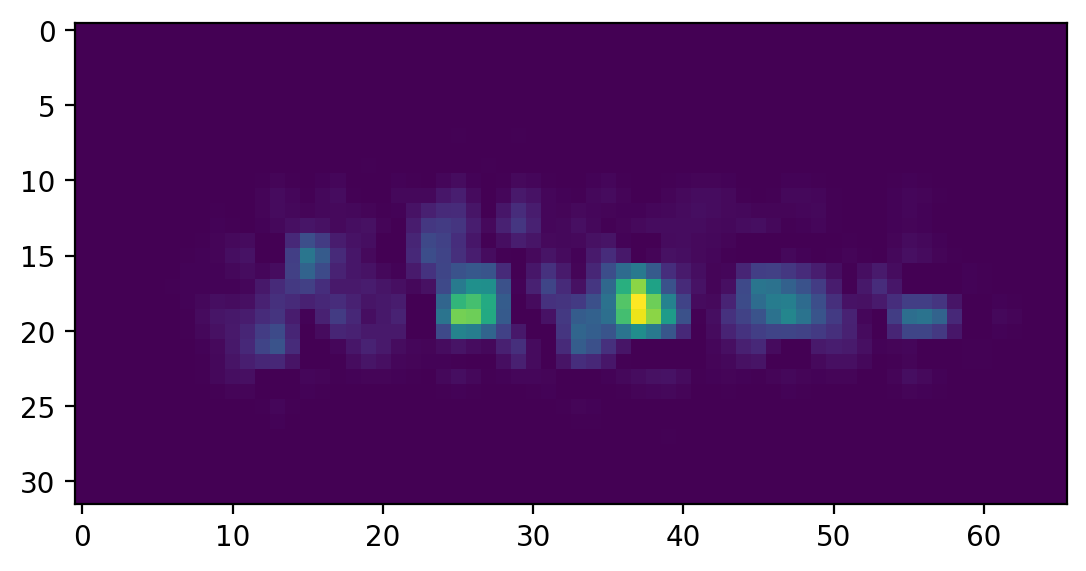

In [188]:
recon_img = reconstruction.value
recon_img[recon_img < 0] = 0
plt.imshow(recon_img)